# 4. 识别边界与模拟

## 学习目标
演示混杂如何影响估计，避免把调整回归自动称为因果。

**数据来源：** 原有方法实验使用 `aiv/data.py` 的确定性合成样本；本页后半部读取 `results/final-analysis/` 的真实聚合观察或条件分析。两类结果分别标明范围。

## 运行准备
在项目环境中从干净内核运行全部单元。默认不读取 .env、不调用 API。

In [1]:
from pathlib import Path
import sys, json

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "aiv").is_dir())
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
from aiv.data import synthetic_records

records = synthetic_records(seed=26)
LIVE_API = False  # Explicit opt-in only. Default cells never spend credits.
from aiv.notebook_materials import configure_style, save_figure
configure_style()

## 已知真值实验

,model,estimate,lower,upper,p,true_effect,source
0,naive,1.0953,0.9474,1.2432,0.0,0.4,synthetic_known_truth
1,adjusted,0.4792,0.3438,0.6146,0.0,0.4,synthetic_known_truth


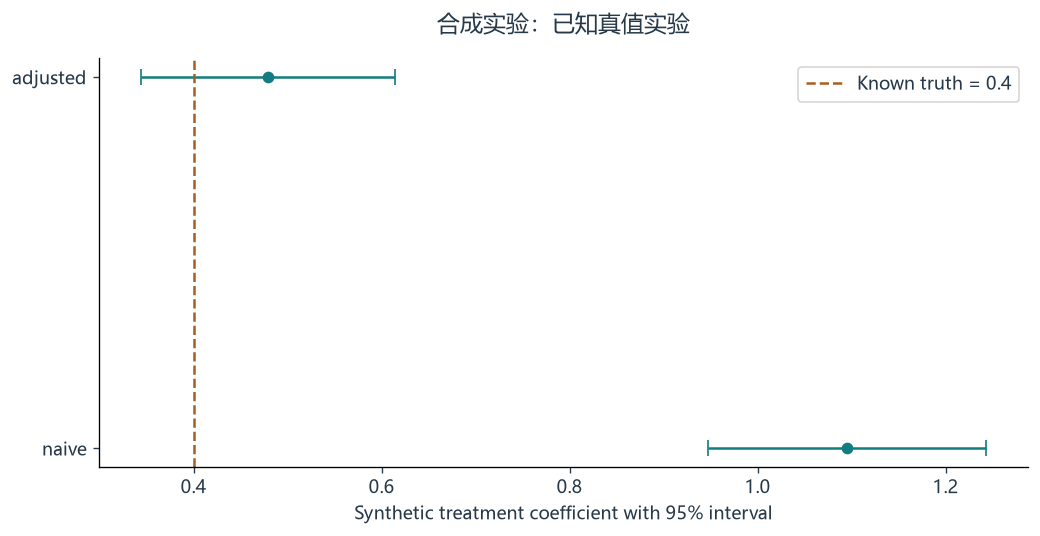

In [2]:
from aiv.analysis import causal_simulation

result = causal_simulation()
display(result.round(4))
y = np.arange(len(result))
plt.errorbar(
    result.estimate,
    y,
    xerr=[result.estimate - result.lower, result.upper - result.estimate],
    fmt="o",
    color="#137c80",
    capsize=5,
)
plt.axvline(0.4, color="#a65f22", linestyle="--", label="Known truth = 0.4")
plt.yticks(y, result.model)
plt.xlabel("Synthetic treatment coefficient with 95% interval")
plt.legend()
plt.tight_layout()
save_figure(plt.gcf(), 'synthetic-04-01', '合成实验：已知真值实验', kind='synthetic', sources=['aiv/data.py', 'aiv/analysis.py', 'aiv/metrics.py'], notebook='04_识别边界与模拟.ipynb')
plt.show()

真效应设为 0.4，调整模型纳入了生成机制中的真实混杂因素。真实数据中不可验证不存在遗漏混杂，因而不能照搬此结论。

## 真实数据识别检查表

In [3]:
display(
    pd.DataFrame(
        {
            "requirement": [
                "独立前测/后测",
                "可比处理组与对照组",
                "处理前协变量",
                "跨学期共同锚定任务",
                "学生簇与逐回合时间顺序",
            ],
            "current_status": ["未发现", "未建立", "有限", "未发现", "学生簇可用；逐回合时间戳缺失"],
        }
    )
)

,requirement,current_status
0,独立前测/后测,未发现
1,可比处理组与对照组,未建立
2,处理前协变量,有限
3,跨学期共同锚定任务,未发现
4,学生簇与逐回合时间顺序,学生簇可用；逐回合时间戳缺失


过程关联也须具有可靠的时间顺序。当前逐回合时间戳缺失，严格前瞻关联尚无合格样本；独立学习增量另需结果、对照与处理前信息。

## 计算检查

In [4]:
assert result.source.eq("synthetic_known_truth").all()
assert result.true_effect.eq(0.4).all()

## 继续研究
新增随机或准实验设计、共同任务和无AI迁移测验；预先定义处理、结果、协变量与泄漏检查。

## 真实资料：严格时间顺序检查
B 的次级关联分析要求可观测的逐回合时间、严格晚于暴露的候选结果及足够学生簇。
源 CSV 创建时间描述来源记录，不能回填为学生每次提问的发生时间；相同时间戳也不构成先后顺序。
来源：`results/final-analysis/summary.json` 的 `association`。

In [5]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from aiv.notebook_materials import configure_style, save_figure
configure_style()
FINAL_DIR = ROOT / "results" / "final-analysis"
_final_summary_path = FINAL_DIR / "summary.json"
final_summary = json.loads(_final_summary_path.read_text(encoding="utf-8")) if _final_summary_path.is_file() else None

def final_csv(name):
    return pd.read_csv(FINAL_DIR / name) if final_summary is not None else pd.DataFrame()

if final_summary is None:
    display(Markdown("本目录未附真实聚合分析；以下真实结果保持空白，前面的合成实验仍可复算。"))
else:
    display(pd.DataFrame([{
        "分析输入": "results/final-analysis/summary.json",
        "冻结修订": final_summary["source"]["revision"],
        "快照清单 SHA-256": final_summary["source"]["manifest_sha256"],
        "真实回合": final_summary["denominators"]["real_turns"],
        "学生—学期": final_summary["denominators"]["student_terms"],
    }]))

,分析输入,冻结修订,快照清单 SHA-256,真实回合,学生—学期
0,results/final-analysis/summary.json,t3,7e885ceecf12a180349369ed9ddfc962ad71f1ea270f68...,3515,401


In [6]:
if final_summary is not None:
    association = final_summary["association"]
    checks_b = pd.DataFrame([
        ["全部真实回合", association["input_real_turns"]],
        ["任务候选回合", association["input_candidate_turns"]],
        ["已观测逐回合时间戳", association["observed_turn_timestamps"]],
        ["符合严格晚于条件的记录", association["eligible_records"]],
        ["符合条件的学生簇", association["student_clusters"]],
        ["事前最少记录门槛", association["minimum_records"]],
        ["事前最少学生簇门槛", association["minimum_students"]],
    ], columns=["检查项目", "数量"])
    display(checks_b)
    display(Markdown(f"**当前状态：{association['status']}。** 逐回合时间戳为 {association['observed_turn_timestamps']}；可进入严格前瞻关联的记录和学生簇均为 0，因此未拟合模型、未评估设计矩阵秩。"))
    assert association["observed_turn_timestamps"] == association["eligible_records"] == association["student_clusters"] == 0

,检查项目,数量
0,全部真实回合,3515
1,任务候选回合,1010
2,已观测逐回合时间戳,0
3,符合严格晚于条件的记录,0
4,符合条件的学生簇,0
5,事前最少记录门槛,100
6,事前最少学生簇门槛,30


**当前状态：unavailable。** 逐回合时间戳为 0；可进入严格前瞻关联的记录和学生簇均为 0，因此未拟合模型、未评估设计矩阵秩。

下一步应在采集时记录逐回合时间和会话关系，再检查前瞻样本门槛、设计矩阵及学生簇。
因果学习增量还需要明确干预、独立学习结果、处理前基础和可比条件。达到 100 条/30 簇工程门槛本身不保证统计功效。